# A4 - Optimisation Stochastique de Protocoles Pharmaceutiques

> **Sujet** : Déterminer les dosages et calendriers d'administration de médicaments chimiothérapeutiques qui maximisent l'efficacité thérapeutique tout en minimisant les effets toxiques, en tenant compte de l'incertitude sur la réponse patient

## Plan
### I - Modèle pharmacocinétique
### II - Profils de patients synthétiques
### III - Optimisation déterministe (CP-SAT)
### IV - Scénarios stochastiques + SAA
### V - Optimisation robuste (minimax)
### VI - Comparaisons des trois approches
### VII - Analyse de sensibilité sur $\lambda$
### VIII - Expérience sur population
### IX - Conclusion

**Références :**
- Agur et al. (1996). *Cell Proliferation*, 29(6), 359-374.
- Fiandaca et al. (2022). *Cancers*, 14(17), 4101.
- Bertsimas et al. (2016). *INFORMS Journal on Computing*.
- OR-Tools CP-SAT - [Google Developers](https://developers.google.com/optimization/cp/cp_solver)

## Imports & Configuration

In [3]:
import sys

!{sys.executable} -m pip install numpy
!{sys.executable} -m pip install pandas
!{sys.executable} -m pip install matplotlib
!{sys.executable} -m pip install ortools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from dataclasses import dataclass, field
from typing import List, Dict, Optional
import time, os, warnings
warnings.filterwarnings('ignore')

from ortools.sat.python import cp_model

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True,
    'grid.alpha': 0.3, 'font.size': 11,
})

os.makedirs('figures', exist_ok=True)

COLORS = dict(
    deterministic='#2563EB', stochastic='#16A34A',
    robust='#DC2626', teal='#0D9488', orange='#F97316',
)

print('Imports OK — OR-Tools CP-SAT disponible')


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: /home/thejollycrabtheorist/epita/scia/programmation-par-contrainte/prog-par-contrainte/bin/python -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: /home/thejollycrabtheorist/epita/scia/programmation-par-contrainte/prog-par-contrainte/bin/python -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: /home/thejollycrabtheorist/epita/scia/programmation-par-contrainte/prog-par-contrainte/bin/python -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: /home/thejollycrabtheorist/epita/scia/programmation-par-contrainte/prog-par-contrainte/bin/python -m pip install --upgrade pip
Imports OK — OR-Tools CP-SAT disponible


## I - Modèle Pharmacocinétique (PK)

### Modèle à un comportement - IV bolus
$$
C(t) = \frac{\text{Dose}}{V_d} \cdot e^{-k_e(t-t_{\text{admin}})} \quad \text{avec} \quad k_e = \frac{\ln(2)}{t_{\frac{1}{2}}}
$$

**Superposition linéaire** pour les protocoles multi-doses :

$$
C_{\text{total}}(t) = \sum_{i=1}^{N} \frac{d_i}{V_d} \cdot e^{-k_e(t - t_i)} \cdot \mathbb{1}[t \geq t_i]
$$

### Métriques cliniques

**Efficacité :**

$$
p_{\text{rep}} \cdot \frac{\int_0^T \mathbb{1}[C \geq C_{\min}]\,dt}{T}
$$

Fraction du temps en zone thérapeutique × probabilité de réponse

**Toxicité :**

$$
\frac{\int_0^T \max(C - \frac{C_{\max,\text{safe}}}{\text{sens}}, 0)\,dt}{\frac{C_{\max,\text{safe}}}{\text{sens}} \cdot T}
$$

Dépassement normalisé du seuil de toxicité effectif du patient

**Objectif :**

$$
\text{Eff} - \lambda \cdot \text{Tox}
$$

Trade-off paramétré par $\lambda \geq 0$

In [4]:
# ═══════════════════════════════════════════════════════════════
# 1.1 — STRUCTURES DE DONNÉES ET FONCTIONS PK
# ═══════════════════════════════════════════════════════════════

@dataclass
class PKParameters:
    """Paramètres pharmacocinétiques (modèle mono-compartimentaire)."""
    name: str
    ke: float          # taux d'élimination (h⁻¹)
    vd: float          # volume de distribution (L)
    t_half: float      # demi-vie (h)
    cmax_safe: float   # concentration max tolérée (mg/L)
    cmin_eff: float    # concentration min efficace (mg/L)
    cum_dose_max: float # dose cumulée max sur le cycle (mg)


@dataclass
class Patient:
    """Profil patient avec variabilité inter-individuelle."""
    pid: str
    bsa: float            # surface corporelle (m²)
    age: int
    renal_factor: float   # facteur rénal (modifie ke)
    hepatic_factor: float # facteur hépatique (modifie vd)
    sensitivity: float    # sensibilité à la toxicité (modifie cmax_safe)
    p_response: float     # probabilité de réponse tumorale

    def adjusted_pk(self, base: PKParameters) -> PKParameters:
        """Paramètres PK ajustés pour ce patient."""
        ke_adj = base.ke * self.renal_factor
        vd_adj = base.vd * self.hepatic_factor * (self.bsa / 1.73)
        return PKParameters(
            name=base.name,
            ke=ke_adj, vd=vd_adj,
            t_half=np.log(2) / ke_adj,
            cmax_safe=base.cmax_safe / self.sensitivity,
            cmin_eff=base.cmin_eff,
            cum_dose_max=base.cum_dose_max * self.bsa / 1.73,
        )


@dataclass
class TreatmentWindow:
    horizon_days: int = 28
    n_max_doses: int = 6
    interval_min_days: int = 3
    dose_levels_per_m2: List[float] = field(
        default_factory=lambda: [0, 25, 50, 75, 100]
    )


@dataclass
class OptResult:
    status: str
    doses: List[float]
    times_days: List[int]
    cum_dose: float
    eff: float
    tox: float
    obj: float
    model: str
    ms: float
    pid: str = ''


# ── Fonctions PK ──────────────────────────────────────────────

def pk_iv(dose, pk, t):
    """Concentration IV bolus : C(t) = (D/Vd) * exp(-ke*t)"""
    return (dose / pk.vd) * np.exp(-pk.ke * np.maximum(t, 0))


def pk_multi(doses, admin_h, pk, t_eval):
    """Superposition linéaire multi-doses."""
    c = np.zeros_like(t_eval, dtype=float)
    for d, ta in zip(doses, admin_h):
        m = t_eval >= ta
        c[m] += pk_iv(d, pk, t_eval[m] - ta)
    return c


def calc_efficacy(c, t, pk, p_resp=0.7):
    dt = np.diff(t)
    return float(min(np.sum((c[:-1] >= pk.cmin_eff) * dt) / (t[-1]-t[0]) * p_resp, 1.0))


def calc_toxicity(c, t, pk, sensitivity=1.0):
    thresh = pk.cmax_safe / sensitivity
    excess = np.maximum(c - thresh, 0)
    ref = thresh * (t[-1] - t[0])
    return float(min(np.trapezoid(excess, t) / ref, 1.0)) if ref > 0 else 0.0


def calc_obj(c, t, pk, p_resp, sensitivity, lam):
    return calc_efficacy(c, t, pk, p_resp) - lam * calc_toxicity(c, t, pk, sensitivity)


# ── Catalogue de médicaments ──────────────────────────────────

DRUGS = {
    'doxorubicin': PKParameters(
        'Doxorubicine', ke=np.log(2)/30, vd=809,
        t_half=30, cmax_safe=0.05, cmin_eff=0.005,
        cum_dose_max=550*1.73),
    'fluorouracil': PKParameters(
        '5-Fluorouracile', ke=np.log(2)/0.17, vd=22,
        t_half=0.17, cmax_safe=0.8, cmin_eff=0.2,
        cum_dose_max=2400*1.73),
    'carboplatin': PKParameters(
        'Carboplatine', ke=np.log(2)/5.5, vd=16,
        t_half=5.5, cmax_safe=8.0, cmin_eff=2.0,
        cum_dose_max=6000*1.73),
    'paclitaxel': PKParameters(
        'Paclitaxel', ke=np.log(2)/13, vd=227,
        t_half=13, cmax_safe=0.1, cmin_eff=0.01,
        cum_dose_max=1750*1.73),
}

print('Médicaments modélisés :')
for k, pk in DRUGS.items():
    print(f'  {pk.name:20s}  t½={pk.t_half:6.2f}h  '
          f'Vd={pk.vd:5.0f}L  Cmax={pk.cmax_safe:.3f}  Cmin={pk.cmin_eff:.4f} mg/L')

Médicaments modélisés :
  Doxorubicine          t½= 30.00h  Vd=  809L  Cmax=0.050  Cmin=0.0050 mg/L
  5-Fluorouracile       t½=  0.17h  Vd=   22L  Cmax=0.800  Cmin=0.2000 mg/L
  Carboplatine          t½=  5.50h  Vd=   16L  Cmax=8.000  Cmin=2.0000 mg/L
  Paclitaxel            t½= 13.00h  Vd=  227L  Cmax=0.100  Cmin=0.0100 mg/L


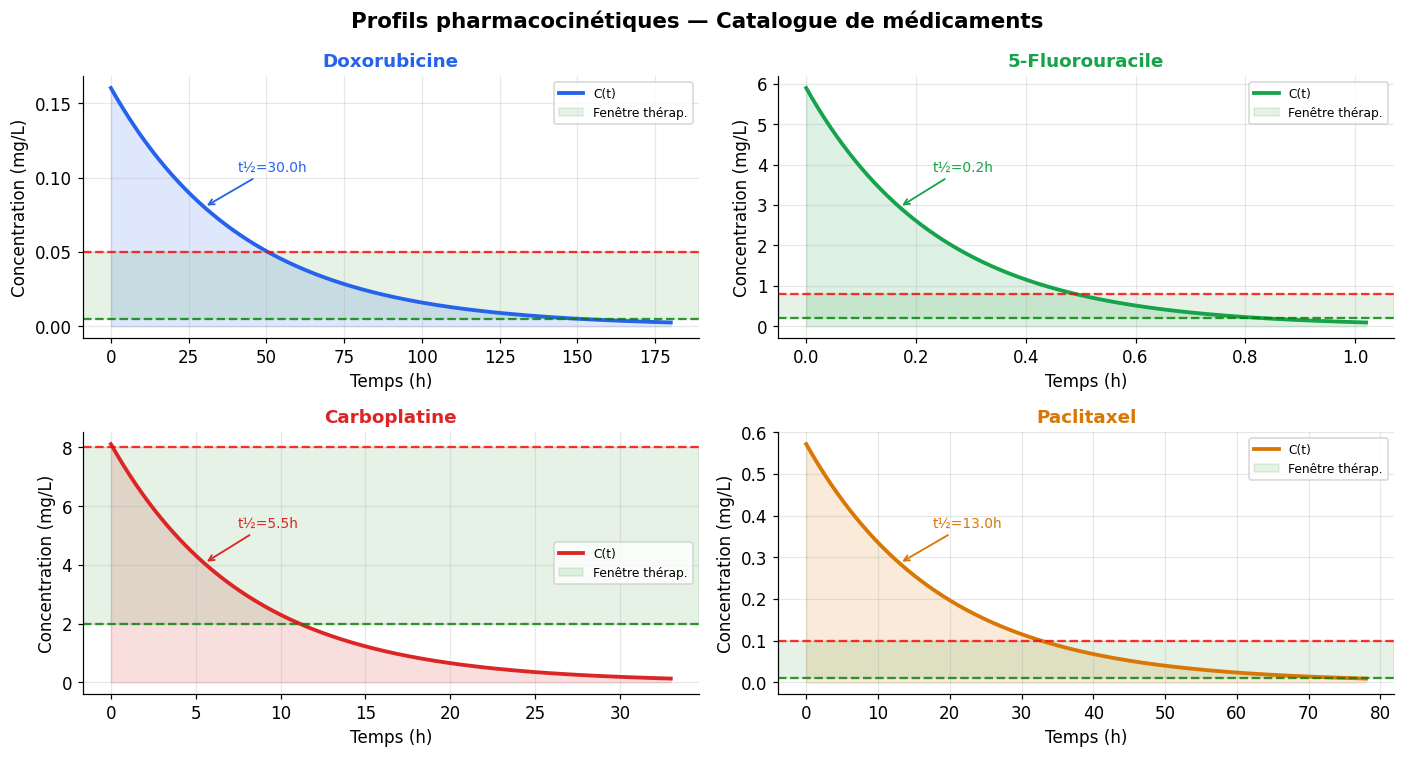

Zone verte = fenêtre thérapeutique [Cmin_eff, Cmax_safe]


In [5]:
# ── Visualisation des profils PK ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle('Profils pharmacocinétiques — Catalogue de médicaments', fontsize=14, fontweight='bold')
colors_pk = ['#2563EB', '#16A34A', '#DC2626', '#D97706']

for ax, (name, pk), col in zip(axes.flat, DRUGS.items(), colors_pk):
    T_h = pk.t_half * 6
    t = np.linspace(0, T_h, 1000)
    dose_abs = 75 * 1.73  # mg
    c = pk_iv(dose_abs, pk, t)

    ax.fill_between(t, c, alpha=0.15, color=col)
    ax.plot(t, c, color=col, lw=2.5, label='C(t)')
    ax.axhspan(pk.cmin_eff, pk.cmax_safe, alpha=0.10, color='green', label='Fenêtre thérap.')
    ax.axhline(pk.cmax_safe, color='red',   ls='--', lw=1.5, alpha=0.8)
    ax.axhline(pk.cmin_eff,  color='green', ls='--', lw=1.5, alpha=0.8)

    c_half = pk_iv(dose_abs, pk, np.array([pk.t_half]))[0]
    ax.annotate(f't½={pk.t_half:.1f}h',
                xy=(pk.t_half, c_half),
                xytext=(pk.t_half + T_h*0.06, c_half * 1.3),
                fontsize=9, color=col,
                arrowprops=dict(arrowstyle='->', color=col, lw=1.2))

    ax.set_title(pk.name, fontsize=12, fontweight='bold', color=col)
    ax.set_xlabel('Temps (h)')
    ax.set_ylabel('Concentration (mg/L)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('figures/01_profils_pk.png', dpi=130, bbox_inches='tight')
plt.show()
print('Zone verte = fenêtre thérapeutique [Cmin_eff, Cmax_safe]')

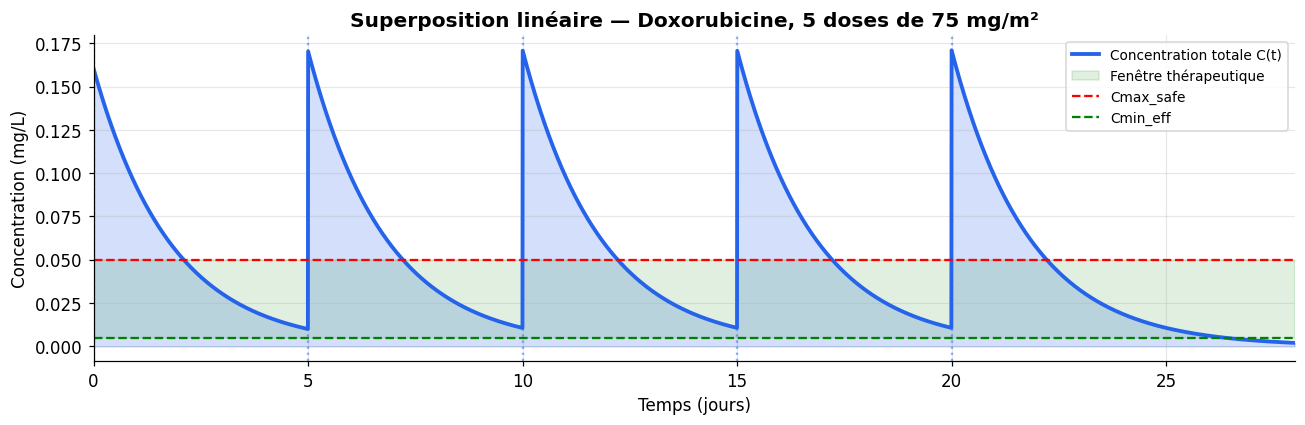

Efficacité=0.659  Toxicité=0.373  Dose cumulée=649mg


In [6]:
# ── Démo superposition multi-doses ────────────────────────────────────────
pk_demo = DRUGS['doxorubicin']
T_eval = np.linspace(0, 28*24, 5000)
doses_demo = [75 * 1.73] * 5
days_demo  = [0, 5, 10, 15, 20]
hours_demo = [d * 24 for d in days_demo]
c_demo     = pk_multi(doses_demo, hours_demo, pk_demo, T_eval)

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(T_eval/24, c_demo, alpha=0.2, color='#2563EB')
ax.plot(T_eval/24, c_demo, '#2563EB', lw=2.5, label='Concentration totale C(t)')
ax.axhspan(pk_demo.cmin_eff, pk_demo.cmax_safe, alpha=0.12, color='green', label='Fenêtre thérapeutique')
ax.axhline(pk_demo.cmax_safe, color='red',   ls='--', lw=1.5, label=f'Cmax_safe')
ax.axhline(pk_demo.cmin_eff,  color='green', ls='--', lw=1.5, label=f'Cmin_eff')
for d in days_demo:
    ax.axvline(d, color='#2563EB', ls=':', alpha=0.5)
ax.set_xlabel('Temps (jours)'); ax.set_ylabel('Concentration (mg/L)')
ax.set_title(f'Superposition linéaire — {pk_demo.name}, 5 doses de 75 mg/m²', fontweight='bold')
ax.legend(fontsize=9); ax.set_xlim(0, 28)
plt.tight_layout()
plt.savefig('figures/02_superposition.png', dpi=130, bbox_inches='tight')
plt.show()

eff_d = calc_efficacy(c_demo, T_eval, pk_demo)
tox_d = calc_toxicity(c_demo, T_eval, pk_demo)
print(f'Efficacité={eff_d:.3f}  Toxicité={tox_d:.3f}  Dose cumulée={sum(doses_demo):.0f}mg')

## II - Profils de Patients Synthétiques

La variabilité inter-patient est modélisée par des **distributions log-normales** (CV ≈ 25–35%) :

| Paramètre | Distribution | Effet |
|-----------|-------------|-------|
| `renal_factor` | LogNormal(0, σ=0.30) | Modifie $k_e$ (clearance rénale) |
| `hepatic_factor` | LogNormal(0, σ=0.25) | Modifie $V_d$ (métabolisme hépatique) |
| `sensitivity` | LogNormal(0, σ=0.35) | Modifie $C_{\max,\text{safe}}$ effectif |
| `p_response` | Beta(3, 1.5) | Probabilité de réponse tumorale |
| `bsa` | Normal(1.73, 0.18) | Surface corporelle, détermine la dose absolue |

In [7]:
# ═══════════════════════════════════════════════════════════════
# 2.1 — GÉNÉRATION DE PATIENTS SYNTHÉTIQUES
# ═══════════════════════════════════════════════════════════════

def generate_patients(n=20, seed=42):
    """
    Génère une population synthétique de patients avec variabilité inter-individuelle.
    
    Les paramètres sont tirés de distributions probabilistes se voulant réalistes :
    - BSA et âge ~ distributions normales tronquées
    - Facteurs rénal, hépatique,sensibilité ~ lognormales pour une variabilité biologique asymétrique
    - probabilité de réponse ~ distribution bêta
    
    Args:
        n (int): nombre de patients à générer
        seed (int): graine aléatoire pour reproductibilité
        
    Returns:
        List[Patient]: population synthétique
    """
    rng = np.random.default_rng(seed)
    return [
        Patient(
            pid=f'P{i+1:02d}',
            bsa=float(np.clip(rng.normal(1.73, 0.18), 1.2, 2.4)),
            age=int(np.clip(rng.normal(55, 12), 25, 80)),
            renal_factor=float(rng.lognormal(0, 0.30)),
            hepatic_factor=float(rng.lognormal(0, 0.25)),
            sensitivity=float(rng.lognormal(0, 0.35)),
            p_response=float(np.clip(rng.beta(3, 1.5), 0.1, 0.98)),
        )
        for i in range(n)
    ]


def generate_scenarios(base, n=40, seed=0):
    """Perturbations autour d'un patient de base (incertitude paramétrique)."""
    rng = np.random.default_rng(seed)
    return [
        Patient(
            pid=f'{base.pid}_s{s:02d}',
            bsa=float(np.clip(rng.normal(base.bsa, 0.12*base.bsa), 1.2, 2.4)),
            age=base.age,
            renal_factor=float(base.renal_factor * rng.lognormal(0, 0.22)),
            hepatic_factor=float(base.hepatic_factor * rng.lognormal(0, 0.18)),
            sensitivity=float(base.sensitivity * rng.lognormal(0, 0.28)),
            p_response=float(np.clip(base.p_response + rng.normal(0, 0.09), 0.05, 0.98)),
        )
        for s in range(n)
    ]


patients = generate_patients(20, seed=42)
df_pat = pd.DataFrame([
    {'ID': p.pid, 'BSA': round(p.bsa,2), 'Âge': p.age,
     'Rénal': round(p.renal_factor,3), 'Hépatique': round(p.hepatic_factor,3),
     'Sensibilité': round(p.sensitivity,3), 'P_réponse': round(p.p_response,3)}
    for p in patients
])
print(f'{len(patients)} patients synthétiques générés')
df_pat.head(8)

20 patients synthétiques générés


,ID,BSA,Âge,Rénal,Hépatique,Sensibilité,P_réponse
0,P01,1.78,42,1.252,1.265,0.505,0.552
1,P02,1.58,65,1.263,1.017,1.484,0.685
2,P03,1.89,54,0.946,0.843,1.534,0.746
3,P04,1.80,59,1.138,1.708,0.867,0.493
4,P05,1.71,44,0.781,1.177,1.297,0.718
5,P06,1.77,65,1.069,1.185,1.024,0.942
6,P07,1.65,47,0.921,1.453,0.739,0.845
7,P08,1.84,63,1.269,0.917,0.851,0.943


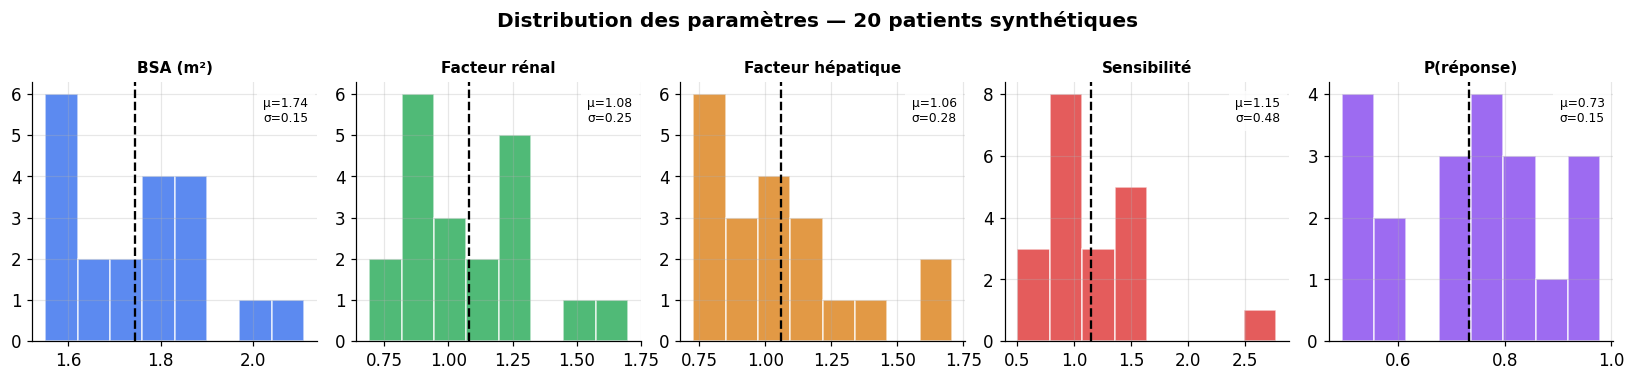

In [8]:
# ── Distribution des paramètres patients ───────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))
fig.suptitle('Distribution des paramètres — 20 patients synthétiques', fontweight='bold')
for ax, (col, label, color) in zip(axes, [
    ('BSA',         'BSA (m²)',          '#2563EB'),
    ('Rénal',       'Facteur rénal',     '#16A34A'),
    ('Hépatique',   'Facteur hépatique', '#D97706'),
    ('Sensibilité', 'Sensibilité',       '#DC2626'),
    ('P_réponse',   'P(réponse)',        '#7C3AED'),
]):
    vals = df_pat[col].values
    ax.hist(vals, bins=8, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(vals.mean(), color='black', ls='--', lw=1.5)
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.text(0.97, 0.94, f'μ={vals.mean():.2f}\nσ={vals.std():.2f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.tight_layout()
plt.savefig('figures/03_distribution_patients.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 3. Optimisation Déterministe avec CP-SAT

### Formulation

$$\max_{\{d_i, t_i\}_{i=1}^N} \; \text{Eff}(C) - \lambda \cdot \text{Tox}(C)$$

| Contrainte | Expression CP-SAT | Motivation clinique |
|-----------|-------------------|--------------------|
| Dose cumulée | $\sum_i d_i \cdot \text{BSA} \leq D_{\max}$ | Cardiotoxicité cumulative |
| Intervalle min | $t_{i+1} - t_i \geq \Delta_{\min}$ | Récupération médullaire |
| Niveaux discrets | $d_i \in \{0, 25, 50, 75, 100\}$ mg/m² | Standardisation clinique |
| Horizon | $t_i \in [0, T]$ jours | Cycle de traitement |
| Variables de présence | $a_i \in \{0,1\}$, $a_i \Leftrightarrow d_i>0$ | Variables booléennes CP |

CP-SAT requiert des **coefficients entiers** → scaling $S=1000$, proxy linéaire pour l'objectif.

In [9]:
# ═══════════════════════════════════════════════════════════════
# 3.1 — OPTIMISEUR DÉTERMINISTE CP-SAT
# ═══════════════════════════════════════════════════════════════

def solve_deterministic(pk, patient, window, lam=2.0, time_limit=30.0):
    """
    Résout le problème de scheduling chimiothérapeutique avec CP-SAT.

    Variables:
      - dose_idx[i] : indice dans dose_levels (entier)
      - admin_day[i]: jour d'administration (entier)
      - active[i]   : indicateur de dose active (booléen)

    Contraintes encodées : dose cumulée, intervalle min, symétrie.
    Objectif proxy : dose totale - λ * pénalité dépassement Cmax.
    """
    pk_adj = patient.adjusted_pk(pk)
    w = window
    S = 1000  # scaling pour entiers
    N = w.n_max_doses

    model = cp_model.CpModel()

    # ── Variables ───────────────────────────────────────────────
    dose_idx  = [model.new_int_var(0, len(w.dose_levels_per_m2)-1, f'di_{i}') for i in range(N)]
    admin_day = [model.new_int_var(0, w.horizon_days, f'day_{i}')             for i in range(N)]
    active    = [model.new_bool_var(f'act_{i}')                               for i in range(N)]

    # Doses absolues scalées (en mg × S)
    levels_sc = [int(d * patient.bsa * S) for d in w.dose_levels_per_m2]
    dose_abs  = []
    for i in range(N):
        dv = model.new_int_var(0, max(levels_sc), f'dabs_{i}')
        model.add_element(dose_idx[i], levels_sc, dv)
        dose_abs.append(dv)

    # ── Contraintes ─────────────────────────────────────────────
    # 1. active ↔ dose_idx > 0
    for i in range(N):
        model.add(dose_idx[i] > 0).only_enforce_if(active[i])
        model.add(dose_idx[i] == 0).only_enforce_if(active[i].negated())

    # 2. Ordre temporel
    for i in range(N-1):
        model.add(admin_day[i] <= admin_day[i+1])

    # 3. Intervalle minimum entre doses actives consécutives
    for i in range(N-1):
        both = model.new_bool_var(f'both_{i}')
        model.add_bool_and([active[i], active[i+1]]).only_enforce_if(both)
        model.add_bool_or([active[i].negated(), active[i+1].negated()]).only_enforce_if(both.negated())
        model.add(admin_day[i+1] - admin_day[i] >= w.interval_min_days).only_enforce_if(both)

    # 4. Dose cumulée maximale
    model.add(sum(dose_abs) <= int(pk_adj.cum_dose_max * S))

    # 5. Symétrie : les slots inactifs sont en fin de liste
    for i in range(N-1):
        model.add(active[i] >= active[i+1])

    # ── Objectif proxy (entier) ──────────────────────────────────
    # Proxy efficacité : dose totale ∝ AUC
    eff_proxy = sum(dose_abs)

    # Proxy toxicité : excès de dose au-delà du seuil Cmax_safe * Vd
    thresh = int(pk_adj.cmax_safe * pk_adj.vd * S * 0.80)
    tox_terms = []
    for i in range(N):
        exc = model.new_int_var(0, max(levels_sc), f'exc_{i}')
        model.add_max_equality(exc, [dose_abs[i] - thresh, model.new_constant(0)])
        tox_terms.append(exc)

    # Bonus espacement (protocole régulier = meilleure récupération)
    spacing = model.new_int_var(0, w.horizon_days * 20, 'sp')
    model.add(spacing == (admin_day[N-1] - admin_day[0]) * 10)

    model.maximize(eff_proxy - int(lam) * sum(tox_terms) + spacing)

    # ── Résolution ───────────────────────────────────────────────
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = time_limit
    solver.parameters.log_search_progress = False
    t0 = time.time()
    code = solver.solve(model)
    ms = (time.time() - t0) * 1000

    status_map = {
        cp_model.OPTIMAL: 'OPTIMAL', cp_model.FEASIBLE: 'FEASIBLE',
        cp_model.INFEASIBLE: 'INFEASIBLE', cp_model.UNKNOWN: 'UNKNOWN',
    }
    status = status_map.get(code, 'UNKNOWN')

    if code not in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        return OptResult(status, [], [], 0, 0, 0, 0, 'det', ms, patient.pid)

    # ── Extraction de la solution ─────────────────────────────────
    sol_doses, sol_days = [], []
    for i in range(N):
        if solver.value(active[i]):
            sol_doses.append(w.dose_levels_per_m2[solver.value(dose_idx[i])] * patient.bsa)
            sol_days.append(solver.value(admin_day[i]))

    # Métriques PK réelles sur le profil obtenu
    t_ev = np.linspace(0, w.horizon_days*24, 3000)
    c = pk_multi(sol_doses, [d*24 for d in sol_days], pk_adj, t_ev)
    eff = calc_efficacy(c, t_ev, pk_adj, patient.p_response)
    tox = calc_toxicity(c, t_ev, pk_adj, patient.sensitivity)

    return OptResult(status, sol_doses, sol_days, sum(sol_doses),
                     eff, tox, eff - lam*tox, 'det', ms, patient.pid)


# ── Test sur le patient P01 ────────────────────────────────────
pk_main = DRUGS['doxorubicin']
p0 = patients[0]
w  = TreatmentWindow()

r_det = solve_deterministic(pk_main, p0, w, lam=2.0)
print(f'Patient {p0.pid}  BSA={p0.bsa:.2f}  Sens={p0.sensitivity:.2f}  P(rép)={p0.p_response:.2f}')
print(f'Statut      : {r_det.status}  ({r_det.ms:.0f} ms)')
print(f'Doses       : {[f"{d:.0f}mg" for d in r_det.doses]}')
print(f'Jours       : {r_det.times_days}')
print(f'Dose cumul. : {r_det.cum_dose:.0f} mg  /  max={p0.adjusted_pk(pk_main).cum_dose_max:.0f} mg')
print(f'Efficacité  : {r_det.eff:.4f}')
print(f'Toxicité    : {r_det.tox:.5f}')
print(f'Objectif    : {r_det.obj:.4f}')

Patient P01  BSA=1.78  Sens=0.51  P(rép)=0.55
Statut      : OPTIMAL  (8 ms)
Doses       : ['89mg', '89mg', '89mg', '89mg', '89mg', '89mg']
Jours       : [0, 3, 6, 22, 25, 28]
Dose cumul. : 535 mg  /  max=982 mg
Efficacité  : 0.3203
Toxicité    : 0.00000
Objectif    : 0.3203


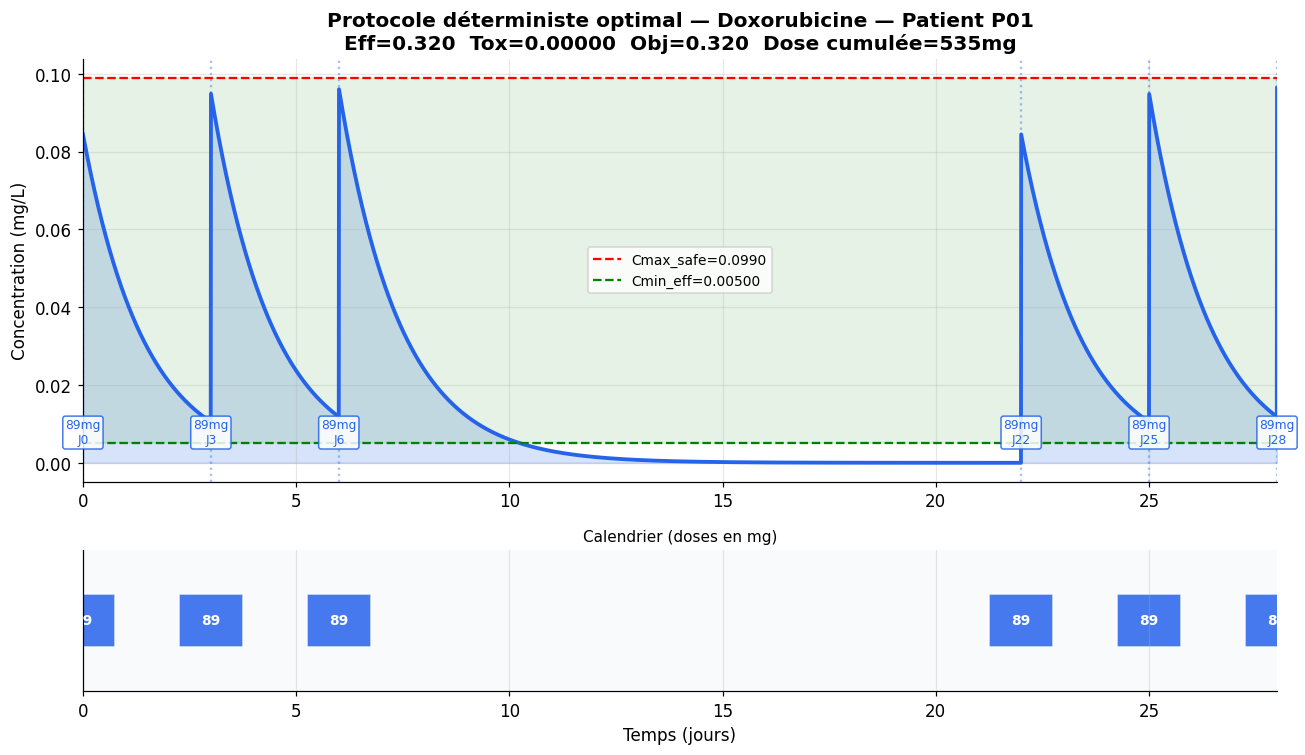

In [10]:
# ── Visualisation protocole déterministe ───────────────────────────────────
pk_adj0 = p0.adjusted_pk(pk_main)
t_ev    = np.linspace(0, 28*24, 5000)
c_det   = pk_multi(r_det.doses, [d*24 for d in r_det.times_days], pk_adj0, t_ev)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), height_ratios=[3,1])

ax1.fill_between(t_ev/24, c_det, alpha=0.18, color=COLORS['deterministic'])
ax1.plot(t_ev/24, c_det, color=COLORS['deterministic'], lw=2.5)
ax1.axhspan(pk_adj0.cmin_eff, pk_adj0.cmax_safe, alpha=0.10, color='green')
ax1.axhline(pk_adj0.cmax_safe, color='red',   ls='--', lw=1.5, label=f'Cmax_safe={pk_adj0.cmax_safe:.4f}')
ax1.axhline(pk_adj0.cmin_eff,  color='green', ls='--', lw=1.5, label=f'Cmin_eff={pk_adj0.cmin_eff:.5f}')
for dose, day in zip(r_det.doses, r_det.times_days):
    ax1.axvline(day, color=COLORS['deterministic'], ls=':', alpha=0.4)
    ax1.annotate(f'{dose:.0f}mg\nJ{day}', xy=(day, pk_adj0.cmax_safe*0.05),
                 ha='center', fontsize=8, color=COLORS['deterministic'],
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.85, edgecolor='#2563EB'))
ax1.set_xlim(0, 28); ax1.set_ylabel('Concentration (mg/L)')
ax1.set_title(f'Protocole déterministe optimal — {pk_main.name} — Patient {p0.pid}\n'
              f'Eff={r_det.eff:.3f}  Tox={r_det.tox:.5f}  Obj={r_det.obj:.3f}  '
              f'Dose cumulée={r_det.cum_dose:.0f}mg', fontweight='bold')
ax1.legend(fontsize=9)

ax2.set_facecolor('#F8FAFC')
for dose, day in zip(r_det.doses, r_det.times_days):
    ax2.barh(0, 1.5, left=day-0.75, height=0.6,
             color=COLORS['deterministic'], alpha=0.85, edgecolor='white')
    ax2.text(day, 0, f'{dose:.0f}', ha='center', va='center',
             fontsize=9, fontweight='bold', color='white')
ax2.set_xlim(0, 28); ax2.set_ylim(-0.8, 0.8); ax2.set_yticks([])
ax2.set_xlabel('Temps (jours)')
ax2.set_title('Calendrier (doses en mg)', fontsize=10)

plt.tight_layout()
plt.savefig('figures/04_protocole_deterministe.png', dpi=130, bbox_inches='tight')
plt.show()